In [1]:
## https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html

In [2]:
#!pip install torchvision

In [3]:
import torch
import os
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image

In [4]:
# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self,root_dir_path,transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations
        
        # List of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]
    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self,idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [5]:
root_dir_path = "./img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178X218 => 178X178
    transforms.Resize(64), # 64X64
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # [-1,1]
])

In [6]:
dataset = ImageProcessor(root_dir_path,transformations)
print(f"loaded {len(dataset)} images")

loaded 15319 images


In [7]:
dataloader = DataLoader(dataset,batch_size=128,shuffle=True)

# Generator Network

In [8]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.nn import BCELoss

In [9]:
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channels=3): # 3 is for RGB
        super(Generator,self).__init__()

        # Fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim,256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,64*64*img_channels),
            nn.Tanh() # [-1,1]
        )
    def forward(self,z):
        img = self.model(z)
        img = img.view(img.size(0),3,64,64)
        return img

        # fake img => 64 X 64 X 3 X batch_size

## Discriminator Network

In [10]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3): # 3 is for RGB
        super(Discriminator,self).__init__()

        # Fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), 
            
            nn.Linear(img_channels*64*64,1024), # 100 => 256
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid() # Probability of being real/fake
        )
    def forward(self,img):
        return self.model(img)

In [11]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [12]:
import torch
# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"device is {device}")

device is cpu


In [13]:
generator = generator.to(device)
discriminator = discriminator.to(device)

## Training the GAN

In [14]:
def train(generator,discriminator,dataloader,epochs=10):
    for epoch in range(epochs):
        for i,imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size,1).to(device)  # [1,1,1...]
            fake_labels = torch.zeros(batch_size,1).to(device)  # [0,0,0...]

            # Train the Discriminator
            d_optimizer.zero_grad()

            z = torch.randn(batch_size,100).to(device)
            fake_imgs = generator(z)

            real_loss = GAN_loss(discriminator(real_imgs),real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            z = torch.randn(batch_size,100).to(device)
            fake_imgs = generator(z)

            g_loss = GAN_loss(
                discriminator(fake_imgs),
                real_labels
            )

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(
                    f"for epoch: [{epoch+1}/{epochs}]...."
                    f"Batch: [{i+1}/{len(dataloader)}]...."
                    f"D Loss: {d_loss.item():.4f}...."
                    f"G Loss: {g_loss.item():.4f}...."
                )

        save_generated_images(generator,epoch,device)

In [15]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator,epoch,device,num_imgs=8):
    z = torch.randn(num_imgs,100).to(device)
    generated_imgs = generator(z).detach().cpu()
    # [-1,1] => [0,1]
    grid = torchvision.utils.make_grid(generated_imgs,nrow=4,normalize=True)

    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: [1/5]....Batch: [1/120]....D Loss: 0.6882....G Loss: 0.6939....
for epoch: [1/5]....Batch: [51/120]....D Loss: 0.3020....G Loss: 0.9299....
for epoch: [1/5]....Batch: [101/120]....D Loss: 0.2560....G Loss: 1.4084....


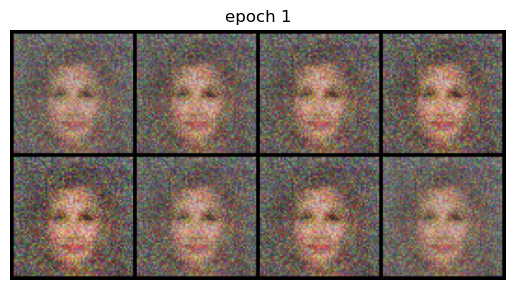

for epoch: [2/5]....Batch: [1/120]....D Loss: 0.4899....G Loss: 0.6614....
for epoch: [2/5]....Batch: [51/120]....D Loss: 0.4717....G Loss: 0.9242....
for epoch: [2/5]....Batch: [101/120]....D Loss: 0.2696....G Loss: 1.0277....


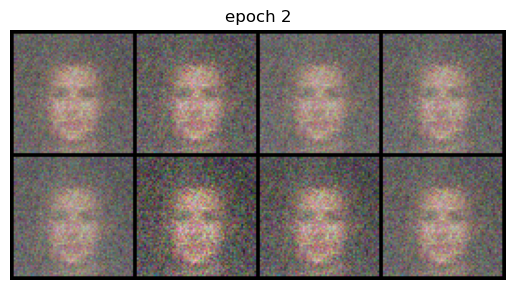

for epoch: [3/5]....Batch: [1/120]....D Loss: 0.2490....G Loss: 0.9897....
for epoch: [3/5]....Batch: [51/120]....D Loss: 0.2861....G Loss: 1.3850....
for epoch: [3/5]....Batch: [101/120]....D Loss: 0.1438....G Loss: 1.6292....


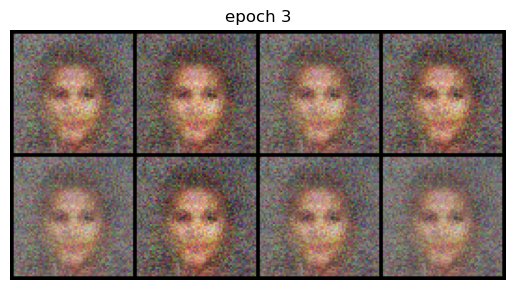

for epoch: [4/5]....Batch: [1/120]....D Loss: 0.1840....G Loss: 2.0188....
for epoch: [4/5]....Batch: [51/120]....D Loss: 0.2336....G Loss: 1.9918....
for epoch: [4/5]....Batch: [101/120]....D Loss: 0.1610....G Loss: 2.3262....


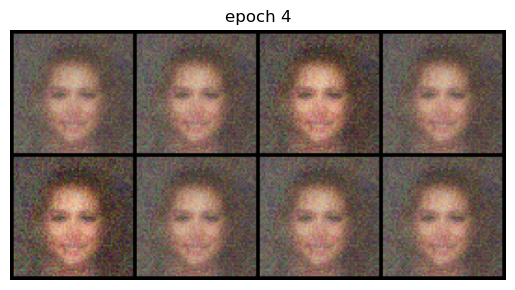

for epoch: [5/5]....Batch: [1/120]....D Loss: 0.2196....G Loss: 3.0636....
for epoch: [5/5]....Batch: [51/120]....D Loss: 0.0598....G Loss: 2.6478....
for epoch: [5/5]....Batch: [101/120]....D Loss: 0.2158....G Loss: 2.1829....


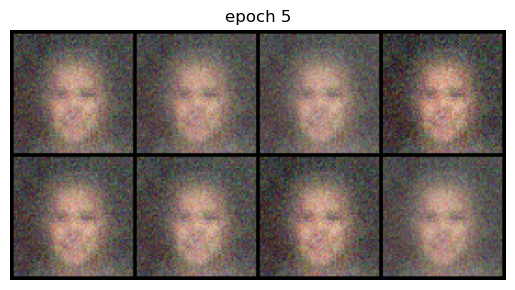

In [16]:
train(generator,discriminator,dataloader,epochs=5)